# Prism coupling

As seen in a previous notebook on total internal reflection, when such a reflection occurs an evanescent wave is generated below the superstrate (which we will call the "prism" here). Total internal reflection is thus a way to generate an evanescent wave. This evanescent wave can then be used to excite any guided mode.

We first consider the excitation of a dielectric waveguide of thickness 500 nm. The prism (refractive index 1.5, just as the waveguide) is placed above the dielectric layer. We compute the reflectance of the whole structure to find at which angle to excite the guided mode. 

In [1]:
from PyMoosh import *
import matplotlib.pyplot as plt
%matplotlib widget
plt.rcParams['figure.dpi'] = 100
from phc_codes.phc_utils import refractive_index, generate_lambda

incidence = 0

ni = refractive_index("Quartz_expt")
nsup = 1.0
nh = refractive_index("TiO2_expt")  # 2.41 + 0.0024j  
nl = refractive_index("SiO2_expt")  # 1.46 + 0.0010j  
nglyc = 1.4722 # glycerol
nfinal = refractive_index("SiO2_expt")#1.43 + 0.002j

# Two materials of different optical index. The larger the difference in index, the more efficient the mirror will be
lmda0 = 520

tl = int(lmda0/(4 * nl(lmda0)))
#print(tl*1.46/2.41)
th = int(lmda0/(4 * nh(lmda0)))
tl_mod = tl
tqz = 0
tfinal = 0
tglyc = 0
tsup = 500

materials = [
        lambda x : ni(x)**2,    #0
        lambda x : nl(x)**2,    #1
        lambda x : nh(x)**2,    #2
        nsup**2,                  #3
        nglyc**2,               #4
        lambda x : nfinal(x)**2, #5
    ]

lay_pairs = 4

stack = [0, 4] + [2, 1] * lay_pairs + [5, 3]
# We stack 2*lay_pairs+1 layers of dielectric materials with alternating index
# We also begin and start with the lower index material
thicknesses = [tqz, tglyc] + [th, tl] * (lay_pairs-1) + [th, tl_mod] + [tfinal, tsup]
prism_coupler = Structure(materials,stack,thicknesses)

print(prism_coupler.thickness, stack)

List of materials:
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (2.16737284+0j)
Custom dispersive material. Epsilon= <lambda> (wavelength in nm)
[0, 0, 52, 88, 52, 88, 52, 88, 52, 88, 0, 500] [0, 4, 2, 1, 2, 1, 2, 1, 2, 1, 5, 3]


C:\Users\Somnath\AppData\Local\Temp\ipykernel_14924\2325059219.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  tl = int(lmda0/(4 * nl(lmda0)))
C:\Users\Somnath\AppData\Local\Temp\ipykernel_14924\2325059219.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  th = int(lmda0/(4 * nh(lmda0)))


## dispersion curve

reflection at different angles

In [2]:
n_lambda = 300
# thicknness range of pva layer 
t_i = 0
t_f = 500
n_t = 100  # thickness sample nos.

wl_i = 400
wl_f = 650

theta_i_deg = 44  # angle of incidence(degree)

# Generating data arrays -----------------------------------------------
LAMBDA = generate_lambda(wl_i, wl_f, n_lambda)
tt_pva = np.linspace(t_i, t_f, n_t)
theta_i = (np.pi / 180) * theta_i_deg  # in radians

Reflectance = np.zeros((n_lambda, n_t))

for l, tfinal in enumerate(tt_pva):
    prism_coupler.thickness[-2] = tfinal
    for k, lmda in enumerate(LAMBDA):
        r, t, R, T = coefficient(prism_coupler, lmda, theta_i, .0)
        Reflectance[k, l] = R


### plot the data

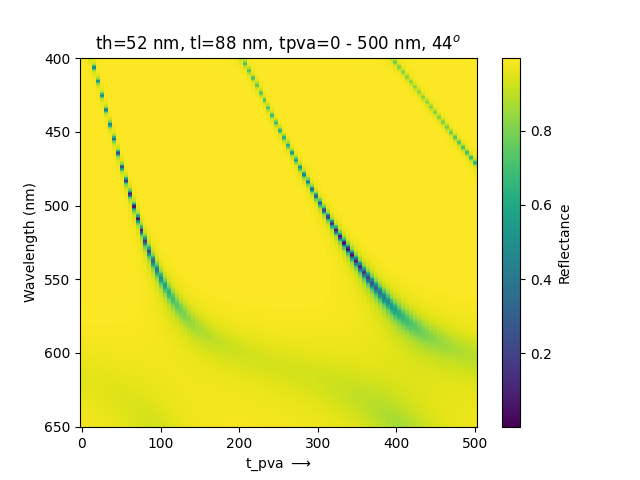

In [3]:

plt.figure(1)
plt.clf()

t_pdms, Lmda = np.meshgrid(tt_pva, LAMBDA)
plt.pcolormesh(t_pdms, Lmda, Reflectance, lw=1)
plt.colorbar(label="Reflectance")
plt.xlabel(r"t_pva $\longrightarrow$")
plt.ylabel(r"Wavelength (nm)")
plt.title(f"th={th} nm, tl={tl} nm, tpva={t_i} - {t_f} nm, {theta_i_deg}$^o$")
plt.gca().invert_yaxis()
plt.show()

## Reflectivity at specific thickness

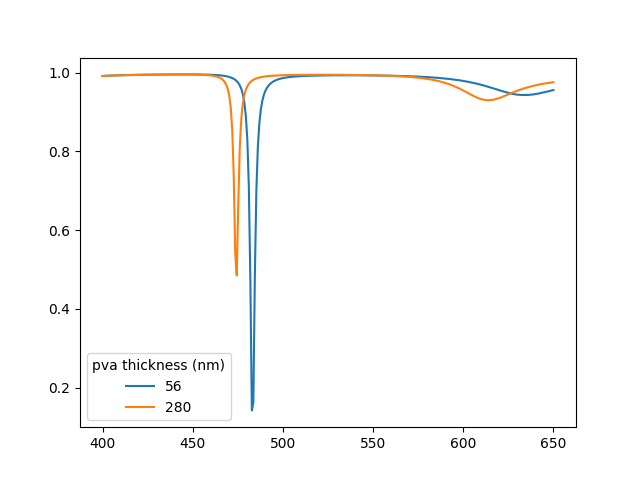

In [4]:
plot_PVA_thickness = [56, 280]
plt.figure(4)
plt.clf()

for t in plot_PVA_thickness:
    plt.plot(LAMBDA, Reflectance[:, np.argmin(np.abs(tt_pva-t))])

plt.legend(plot_PVA_thickness, title="pva thickness (nm)")
plt.show()

Pixels horizontally: 4676
Incidence in degrees: 43.99999999999999
E//, TE, s polarization
Pixels vertically: 130


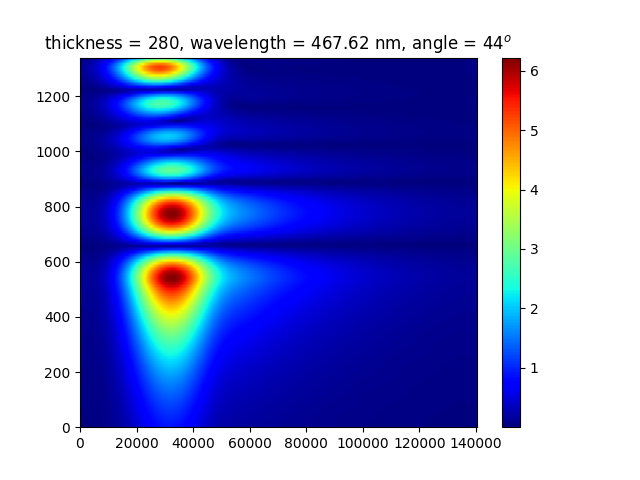

In [5]:
wl = 467.62
pva_thickness = 280
domain = Window(300 * wl, 0.2, 30.0, 10.0)
beam = Beam(wl, theta_i_deg / 180 * np.pi, 0, 30 * wl)

prism_coupler.thickness[-2] = pva_thickness   #pva layer thickness
E = field(prism_coupler, beam, domain)

plt.figure(5)
plt.clf()
plt.imshow(
    abs(E),
    cmap="jet",
    extent=[0, domain.width, 0, sum(prism_coupler.thickness)],
    aspect="auto",
)
plt.colorbar()
plt.title(f"thickness = {pva_thickness}, wavelength = {wl} nm, angle = {theta_i_deg}$^o$")
plt.show()

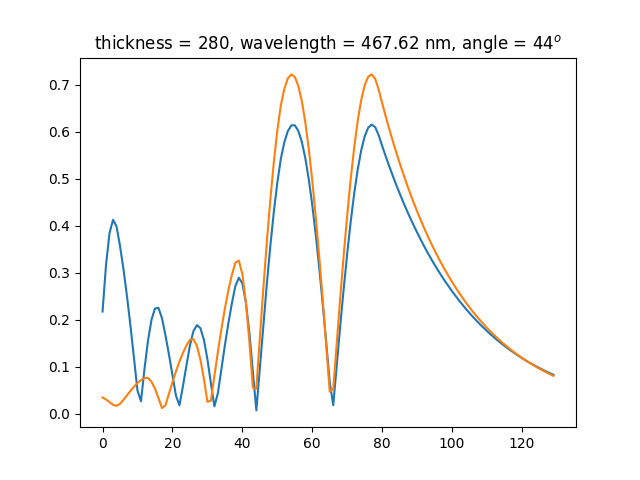

In [6]:
#line plot  of the energy density
plt.figure(6)
plt.clf()
plt.plot(abs(np.sum(E, axis=1)))
plt.plot(abs(E[:, 2800]))
plt.title(f"thickness = {pva_thickness}, wavelength = {wl} nm, angle = {theta_i_deg}$^o$")
plt.show()